In [3]:
#Name:-Huzaifa Bin Anas
#Rollno:- 24F-AI-143
#Project:- Health Risk Classification


In [5]:
# iMPORTING Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)




In [9]:

#ImPORTING dATA SET
hba = pd.read_csv("diabetes.csv")

# Display top 5 rows
hba.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [13]:
#dataset information
#displaying number and columns of dataset
print("\nDataset Shape:")
print(hba.shape)
# Display information about columns and data types
print("\nDataset Information:")
hba.info()
#Checking missing values
print("\nMissing Values:")
print(hba.isnull().sum())

# Check duplicate rows
print("\nNumber of Duplicate Rows:")
print(hba.duplicated().sum())



Dataset Shape:
(768, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                       

In [15]:
#Data Preprocessing
# In this dataset, some health measurements contain zero.
# Zero is not realistic for some health indicators such as
# Glucose, BloodPressure and BMI.
# Therefore, we treat these zero values as missing values.

columns_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace zero values with NaN
hba[columns_with_zero] = hba[columns_with_zero].replace(
    0,
    np.nan
)

# Check missing values after replacing zeros
print("\nMissing Values After Preprocessing:")
print(hba.isnull().sum())



Missing Values After Preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [16]:
# doing data analysis
# Check unique values in every column
print("Unique values in each column:")
print(hba.nunique())

# Check target distribution
print("\nOutcome Distribution:")
print(hba["Outcome"].value_counts())

# Check percentage of each target class
print("\nOutcome Percentage:")
print(hba["Outcome"].value_counts(normalize=True) * 100)

# Check zero values in each column
print("\nZero Values:")
print((hba == 0).sum())

Unique values in each column:
Pregnancies                  17
Glucose                     135
BloodPressure                47
SkinThickness                50
Insulin                     187
BMI                         247
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

Outcome Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome Percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Zero Values:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [17]:
#Seperating Features and target from the data
# X contains the input health indicators
X = hba.drop("Outcome", axis=1)
# y contains the target variable
#
# Outcome:
# 0 = No Diabetes
# 1 = Diabetes
y = hba["Outcome"]
print("\nFeature Columns:")
print(X.columns)
print("\nTarget Column:")
print(y.name)



Feature Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

Target Column:
Outcome


In [18]:
#Splitting The dataset
#80% training data
# 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:")
print(X_train.shape)
print("\nTesting Data Shape:")
print(X_test.shape)




Training Data Shape:
(614, 8)

Testing Data Shape:
(154, 8)


In [20]:
#Handling missing values from the dataset
#Median imputation replaces missing values with
# the median value of the corresponding feature.
imputer = SimpleImputer(strategy="median")
# Learn median values from training data
# and replace missing values
X_train = imputer.fit_transform(X_train)
# Apply the same learned values to testing data
X_test = imputer.transform(X_test)

print("\nMissing values have been handled using median imputation.")


Missing values have been handled using median imputation.


In [22]:
#Feature scaling for SVM algorithm
# StandardScaler puts numerical features on a similar scale.
#
# Scaling is important for SVM because SVM is sensitive
# to differences in feature scales.
scaler = StandardScaler()
# Fit scaler using training data
X_train_scaled = scaler.fit_transform(X_train)
# Apply same scaling to testing data
X_test_scaled = scaler.transform(X_test)


In [25]:
#supportvectorMachine

svm_model = SVC(
    kernel="rbf"
)
# Train SVM using scaled training data
svm_model.fit(
    X_train_scaled,
    y_train
)
# Make predictions on test data
svm_predictions = svm_model.predict(
    X_test_scaled
)
print('SVM model trained')



SVM model trained


In [28]:
#Svm evaluation and result
# Calculating svm performance on dataset
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)
svm_precision = precision_score(
    y_test,
    svm_predictions
)
svm_recall = recall_score(
    y_test,
    svm_predictions
)
svm_f1 = f1_score(
    y_test,
    svm_predictions
)
print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1 Score :", round(svm_f1, 4))


Accuracy : 0.8377
Precision: 0.7636
Recall   : 0.7778
F1 Score : 0.7706



SVM Confusion Matrix:
[[87 13]
 [12 42]]


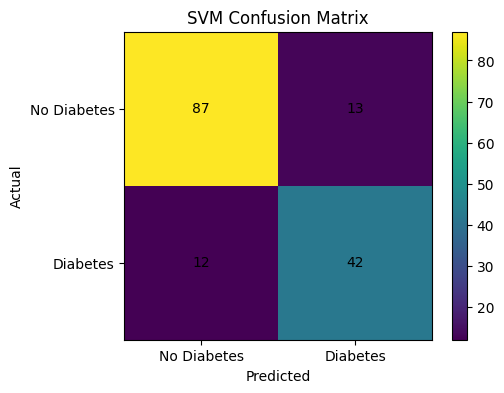

In [29]:
#SVM model confusion metrix
svm_cm = confusion_matrix(
    y_test,
    svm_predictions
)

print("\nSVM Confusion Matrix:")
print(svm_cm)


# display Confusion matrix
plt.figure(figsize=(5, 4))

plt.imshow(svm_cm)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

plt.yticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

# Display value of confusion matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            svm_cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [30]:
#Decision tree model
# maxdepth=5 of the model
#ths help reduce the possibilty of overfitting

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
# Decision Tree does not require feature scaling,
# so we use the imputed but unscaled data.
tree_model.fit(
    X_train,
    y_train
)
# Make predictions
tree_predictions = tree_model.predict(
    X_test
)


In [32]:
#Decision tree evaluation
tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)

tree_precision = precision_score(
    y_test,
    tree_predictions
)

tree_recall = recall_score(
    y_test,
    tree_predictions
)

tree_f1 = f1_score(
    y_test,
    tree_predictions
)

print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1 Score :", round(tree_f1, 4))

Accuracy : 0.8247
Precision: 0.7547
Recall   : 0.7407
F1 Score : 0.7477



Decision Tree Confusion Matrix:
[[87 13]
 [14 40]]


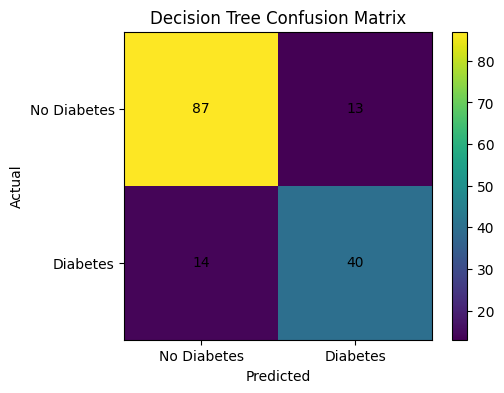

In [35]:
#Decision tree confusion matrix
tree_cm = confusion_matrix(
    y_test,
    tree_predictions
)

print("\nDecision Tree Confusion Matrix:")
print(tree_cm)
# Display Decision Tree confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(tree_cm)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)

plt.yticks(
    [0, 1],
    ["No Diabetes", "Diabetes"]
)
# Display values inside confusion matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            tree_cm[i, j],
            ha="center",
            va="center"
        )
plt.show()

In [36]:
#Comparing both models svm and decisition tree
comparison = pd.DataFrame({

    "Model": [
        "SVM",
        "Decision Tree"
    ],

    "Accuracy": [
        svm_accuracy,
        tree_accuracy
    ],

    "Precision": [
        svm_precision,
        tree_precision
    ],

    "Recall": [
        svm_recall,
        tree_recall
    ],

    "F1 Score": [
        svm_f1,
        tree_f1
    ]
})
print(
    comparison.to_string(
        index=False
    )
)

        Model  Accuracy  Precision   Recall  F1 Score
          SVM  0.837662   0.763636 0.777778  0.770642
Decision Tree  0.824675   0.754717 0.740741  0.747664


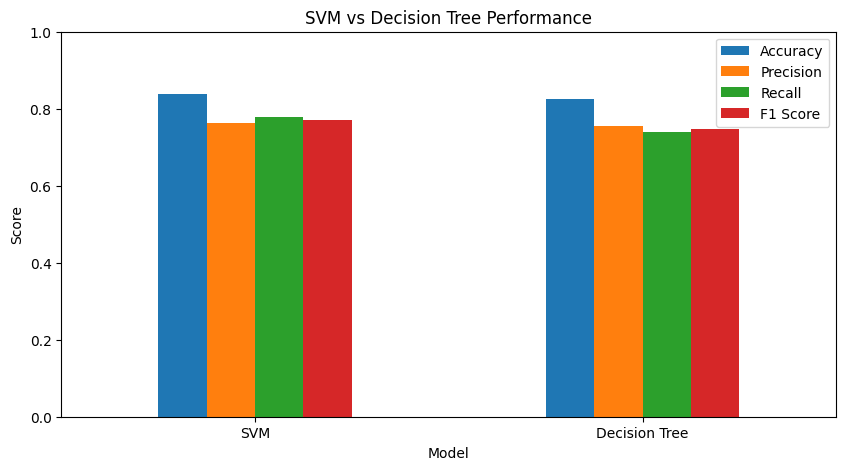

In [37]:
#Model comparison graph
comparison.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("SVM vs Decision Tree Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()



In [39]:
#Checking Overfitting

# Generate predictions on training data.

# SVM training predictions
svm_train_predictions = svm_model.predict(
    X_train_scaled
)

# Decision Tree training predictions
tree_train_predictions = tree_model.predict(
    X_train
)


# Calculate training accuracy

svm_train_accuracy = accuracy_score(
    y_train,
    svm_train_predictions
)

tree_train_accuracy = accuracy_score(
    y_train,
    tree_train_predictions
)
print("\nSVM:")
print(
    "Training Accuracy:",
    round(svm_train_accuracy, 4)
)

print(
    "Testing Accuracy :",
    round(svm_accuracy, 4)
)


print("\nDecision Tree:")
print(
    "Training Accuracy:",
    round(tree_train_accuracy, 4)
)

print(
    "Testing Accuracy :",
    round(tree_accuracy, 4)
)



SVM:
Training Accuracy: 0.8958
Testing Accuracy : 0.8377

Decision Tree:
Training Accuracy: 0.9349
Testing Accuracy : 0.8247


In [40]:
#Result of both model
if svm_accuracy > tree_accuracy:

    print(
        "SVM performed better than Decision Tree "
        "based on test accuracy."
    )

elif tree_accuracy > svm_accuracy:

    print(
        "Decision Tree performed better than SVM "
        "based on test accuracy."
    )

else:

    print(
        "Both models achieved the same test accuracy."
    )


SVM performed better than Decision Tree based on test accuracy.


In [41]:
# CONCLUSION OF THE PROJECT
("""This project used the Pima Indians Diabetes Database
to classify patients as diabetic or non-diabetic.

The dataset was preprocessed by handling unrealistic
zero values as missing values and replacing missing
values using median imputation.

Two classification algorithms were applied:
1. Support Vector Machine (SVM)
2. Decision Tree

Both models were evaluated using Accuracy, Precision,
Recall, F1 Score and Confusion Matrix.

Training and testing accuracy were also compared
to check for possible overfitting.

The final model should be selected by considering
not only accuracy but also precision, recall,
F1 Score and generalization performance.
""")

'This project used the Pima Indians Diabetes Database\nto classify patients as diabetic or non-diabetic.\n\nThe dataset was preprocessed by handling unrealistic\nzero values as missing values and replacing missing\nvalues using median imputation.\n\nTwo classification algorithms were applied:\n1. Support Vector Machine (SVM)\n2. Decision Tree\n\nBoth models were evaluated using Accuracy, Precision,\nRecall, F1 Score and Confusion Matrix.\n\nTraining and testing accuracy were also compared\nto check for possible overfitting.\n\nThe final model should be selected by considering\nnot only accuracy but also precision, recall,\nF1 Score and generalization performance.\n'